# **회귀 문제 인공 신경망 모델 설정 방법**

In [ ]:
# 라이브러리 설치
!pip install koreanize_matplotlib
import koreanize_matplotlib

import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import statsmodels.api as sm
from sklearn.metrics import r2_score;  import random;  import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 34.4 MB/s eta 0:00:00


In [ ]:
df=pd.read_csv("포물선.csv")
df

,target,feature
0,-0.232359,0.000000
1,-0.244998,0.001001
2,-0.238215,0.002002
3,-0.224597,0.003003
4,-0.227336,0.004004
...,...,...
995,-0.241883,0.995996
996,-0.248990,0.996997
997,-0.247060,0.997998
998,-0.260476,0.998999


Text(0, 0.5, '타깃(y)')

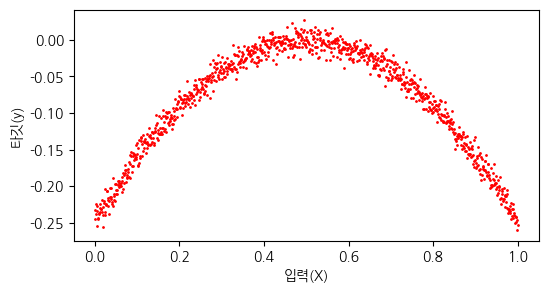

In [ ]:
 # 입력과 타깃 지정
y=df['target']
X=df['feature']

plt.figure(figsize=(6, 3))
plt.scatter(X,y, s=1, color="r")  # s는 점의 크기
plt.xlabel("입력(X)")
plt.ylabel("타깃(y)")

In [ ]:
# 랜덤 시드 고정(모델 설정 전에 실행)
SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 신경망 모형
model=Sequential([
    Input(shape=(1,)),
    Dense(10, activation='relu'),
    Dense(10,  activation='relu'),
    Dense(1)     ])

model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=300)

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0063
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0053
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0040
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016
Epoch 10/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013
Epoch 11/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011
Epoch 12/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.0486e-04
Epoch 13/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.7514e-04
Epoch 14/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7116e-04
Epoch 15/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss:

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


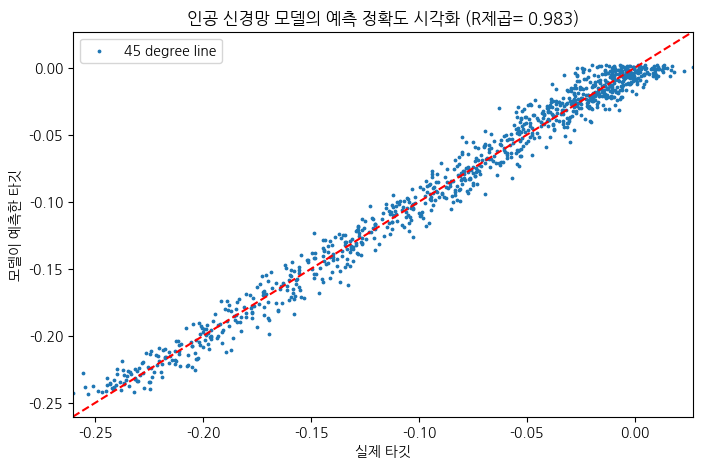

In [ ]:
plt.figure(figsize=(8, 5))

# 타겟 예측 및 R제곱 계산
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

plt.scatter(y, y_pred, s=3, label='45 degree line')
plt.axis([min(y), max(y), min(y), max(y)])
plt.plot([min(y), max(y)], [min(y), max(y)], ls="--", c="r")
plt.xlabel('실제 타깃')
plt.ylabel('모델이 예측한 타깃')
plt.title(f"인공 신경망 모델의 예측 정확도 시각화 (R제곱= {r2:.3f})")
plt.legend(); plt.show()

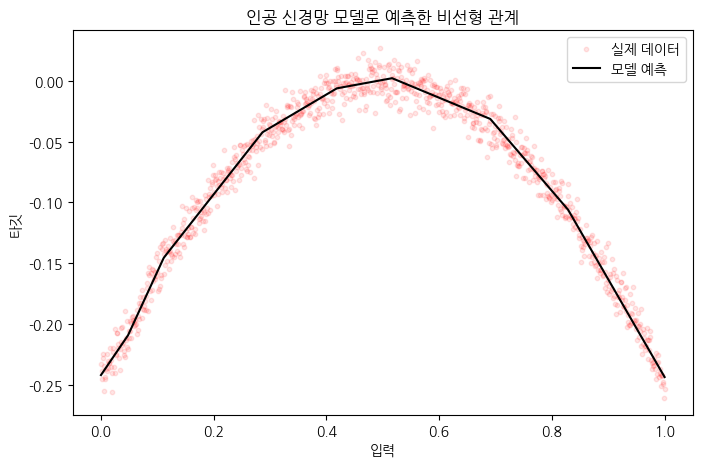

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, s=10, alpha=0.1, color='r', label='실제 데이터')
plt.plot(X, y_pred, "k", label='모델 예측')

plt.title("인공 신경망 모델로 예측한 비선형 관계")
plt.xlabel("입력")
plt.ylabel("타깃")
plt.legend()
plt.show()